In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data,
     data.target.rename("HousePrice")],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


In [8]:
tree = DecisionTreeRegressor(
      random_state=42
)

tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)


train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)


Training RMSE: 3.218325866275131e-16
Testing RMSE: 0.7030445773467542


In [9]:
difference = test_rmse - train_rmse

print("Difference:", difference)

Difference: 0.7030445773467539


In [12]:
cv_scores = cross_val_score(
      tree,
      X_scaled,
      y,
      scoring="neg_root_mean_squared_error",
      cv=5
)

cv_rmse = -cv_scores

print("CV RMSE Scores:")
print(cv_rmse)

print("\nAverage CV RMSE:")
print(cv_rmse.mean())


CV RMSE Scores:
[0.88767617 0.82781619 0.89845112 0.94507041 0.91950207]

Average CV RMSE:
0.8957031908951016


In [13]:
param_grid = {
      "max_depth": [3, 5, 7, 10],
      "min_samples_split": [2, 5, 10]
}


In [14]:
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_root_mean_squared_error')

In [15]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 10}


In [16]:
print("Best CV RMSE:")
print(-grid.best_score_)

Best CV RMSE:
0.6366408923917068


In [17]:
best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

tree_r2 = r2_score(
    y_test,
    y_pred
)

print("RMSE:", tree_rmse)
print("R2:", tree_r2)

RMSE: 0.6454300828015771
R2: 0.6820992539714815


In [18]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(
  y_test,
  lr_pred
)

In [19]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)

ridge_r2 = r2_score(
     y_test,
     ridge_pred
)

In [20]:
results = pd.DataFrame({
    "Model": [
    "Linear Regression",
    "Ridge Regression",
    "Tuned Decision Tree"
    ],
    "RMSE": [
    lr_rmse,
    ridge_rmse,
    tree_rmse
    ],
    "R2 Score": [
    lr_r2,
    ridge_r2,
    tree_r2
    ]
})

results


,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Tuned Decision Tree,0.645430,0.682099


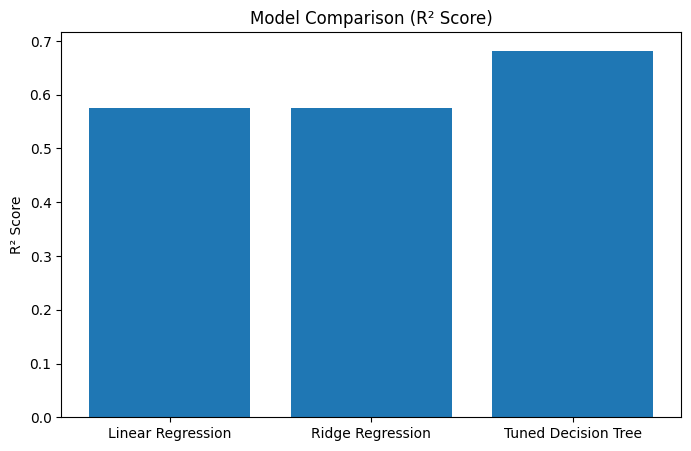

In [21]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()